In [ ]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

In [ ]:
!pip install -q scikit-learn

In [ ]:
from google.colab import files
files.upload()  # select kaggle.json when prompted

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d tongpython/cat-and-dog
!unzip -q cat-and-dog.zip -d cat_dog_data

In [ ]:
import os

train_dir = "cat_dog_data/training_set/training_set"
test_dir = "cat_dog_data/test_set/test_set"

for cls in ["cats", "dogs"]:
    n_train = len(os.listdir(os.path.join(train_dir, cls)))
    n_test = len(os.listdir(os.path.join(test_dir, cls)))
    print(f"{cls}: {n_train} train images, {n_test} test images")

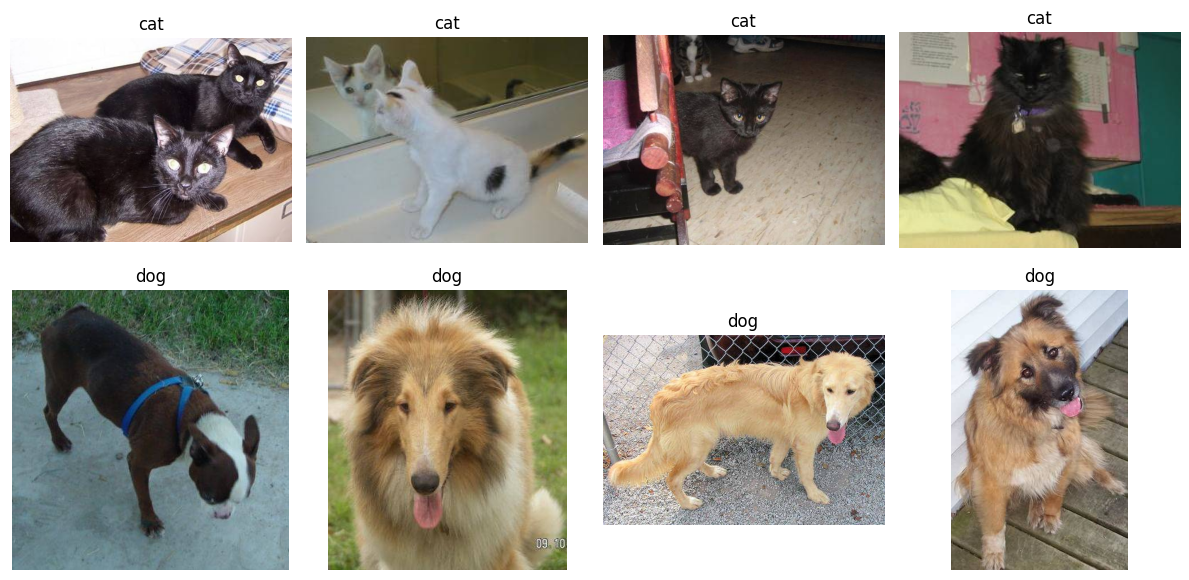

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

cat_files = os.listdir(os.path.join(train_dir, "cats"))[:4]
dog_files = os.listdir(os.path.join(train_dir, "dogs"))[:4]

for i, f in enumerate(cat_files):
    img = Image.open(os.path.join(train_dir, "cats", f))
    axes[0, i].imshow(img)
    axes[0, i].set_title("cat")
    axes[0, i].axis("off")

for i, f in enumerate(dog_files):
    img = Image.open(os.path.join(train_dir, "dogs", f))
    axes[1, i].imshow(img)
    axes[1, i].set_title("dog")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# --- Transforms ---
# Resize every image to 128x128, convert to a PyTorch tensor,
# and normalize pixel values (helps training converge faster/more stably)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),  # converts pixel values from [0,255] to [0,1] and reorders to (C,H,W)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # standard ImageNet stats, works fine here
                          std=[0.229, 0.224, 0.225])
])

# --- Load full training folder as a labeled dataset ---
# ImageFolder automatically labels images based on their subfolder name (cats=0, dogs=1)
full_train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

print("Classes:", full_train_dataset.classes)  # should print ['cats', 'dogs']

# --- Split into train (80%) and validation (20%) ---
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# --- DataLoaders ---
# batch_size=32 means the model sees 32 images at a time during training (a good default)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)   # should be [32, 3, 128, 128]
print("Labels:", labels[:10])          # should show a mix of 0s and 1s

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Convolutional layers: extract visual features
        # in_channels=3 (RGB), out_channels=how many filters/patterns to learn
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Pooling: halves the image size each time (128 -> 64 -> 32 -> 16)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers: after 3 pools, image is 16x16 with 64 channels
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 2)  # 2 output classes: cat, dog

        self.dropout = nn.Dropout(0.3)  # randomly "turns off" 30% of neurons during training to prevent overfitting

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # -> [batch, 16, 64, 64]
        x = self.pool(F.relu(self.conv2(x)))  # -> [batch, 32, 32, 32]
        x = self.pool(F.relu(self.conv3(x)))  # -> [batch, 64, 16, 16]

        x = x.view(x.size(0), -1)  # flatten into a vector per image
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # raw scores (logits) for [cat, dog]
        return x

# Instantiate the model and move it to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CatDogCNN().to(device)
print(model)
print("Using device:", device)

In [ ]:
import torch.optim as optim

# Loss function: measures how far predictions are from true labels
criterion = nn.CrossEntropyLoss()

# Optimizer: updates model weights to reduce loss. Adam is a solid, popular default.
optimizer = optim.Adam(model.parameters(), lr=0.001)  # lr = learning rate: how big each update step is

num_epochs = 10

def train_one_epoch():
    model.train()  # tell model it's in training mode (activates dropout)
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # reset gradients from previous step
        outputs = model(images)        # forward pass
        loss = criterion(outputs, labels)
        loss.backward()                # backpropagation
        optimizer.step()               # update weights

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate():
    model.eval()  # evaluation mode (disables dropout)
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # no need to compute gradients here — saves memory/speed
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# --- Training loop ---
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc = validate()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["cat", "dog"]))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Test Accuracy: 0.7781

Classification Report:
              precision    recall  f1-score   support

         cat       0.76      0.81      0.78      1011
         dog       0.80      0.75      0.77      1012

    accuracy                           0.78      2023
   macro avg       0.78      0.78      0.78      2023
weighted avg       0.78      0.78      0.78      2023

Confusion Matrix:
[[818 193]
 [256 756]]


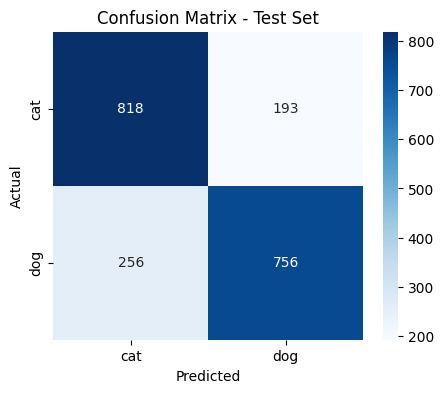

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["cat", "dog"], yticklabels=["cat", "dog"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()